# 性能比较直方图

此 Notebook 根据提供的统计数据生成各种性能指标的直方图。

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题
# 设置绘图样式


## 1. 加载数据

将提供的 CSV 格式的统计数据加载到 Pandas DataFrame中。

In [3]:
csv_data = """Label,File,Mean Offset (µs),Max Absolute Offset (µs),RMS of Offset (µs),Std Dev of Offset (µs),Data Points
a0_b0,timeError_a0_b0_20250222_105437.log,-44.488,101.865,46.437,13.310,7100
a2_b0,timeError_a2_b0_20250222_225514.log,-39.963,376.641,65.645,52.083,7163
a1_b0,timeError_a1_b0_20250222_165456.log,-50.002,226.583,74.546,55.294,7120
a1_b1,timeError_a1_b1_20250222_185502.log,-103.129,181.932,108.314,33.113,6883
a2_b2,timeError_a2_b2_20250223_025527.log,-111.512,557.986,122.149,49.859,7163
a2_b1,timeError_a2_b1_20250223_005521.log,-58.010,581.005,182.794,173.357,7145
a1_b2,timeError_a1_b2_20250222_205508.log,-136.059,348.573,187.083,128.414,6993
a0_b1,timeError_a0_b1_20250222_125443.log,185.951,665.347,188.666,31.892,7162
a0_b2,timeError_a0_b2_20250222_145455（未同步锁定）.log,182.612,1432.293,383.149,336.857,7000
Chrony,timeError.log,-344.017,12289.780,963.358,899.902,7155
"""

df = pd.read_csv(io.StringIO(csv_data))

# 清理列名，去除括号中的单位，方便后续使用
df.columns = [col.split('(')[0].strip() for col in df.columns]

# 将相关列转换为数值类型
numeric_cols = ['Mean Offset', 'Max Absolute Offset', 'RMS of Offset', 'Std Dev of Offset', 'Data Points']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 分离自有方法和 Chrony 的数据
own_methods_df = df[df['Label'] != 'Chrony'].copy()
chrony_df = df[df['Label'] == 'Chrony'].copy()

print("数据加载完成：")
print("自有方法数据:")
print(own_methods_df.head())
print("\nChrony 数据:")
print(chrony_df.head())

数据加载完成：
自有方法数据:
   Label                                 File  Mean Offset  \
0  a0_b0  timeError_a0_b0_20250222_105437.log      -44.488   
1  a2_b0  timeError_a2_b0_20250222_225514.log      -39.963   
2  a1_b0  timeError_a1_b0_20250222_165456.log      -50.002   
3  a1_b1  timeError_a1_b1_20250222_185502.log     -103.129   
4  a2_b2  timeError_a2_b2_20250223_025527.log     -111.512   

   Max Absolute Offset  RMS of Offset  Std Dev of Offset  Data Points  
0              101.865         46.437             13.310         7100  
1              376.641         65.645             52.083         7163  
2              226.583         74.546             55.294         7120  
3              181.932        108.314             33.113         6883  
4              557.986        122.149             49.859         7163  

Chrony 数据:
    Label           File  Mean Offset  Max Absolute Offset  RMS of Offset  \
9  Chrony  timeError.log     -344.017             12289.78        963.358   

   Std Dev o

## 2. 自有方法各项指标直方图

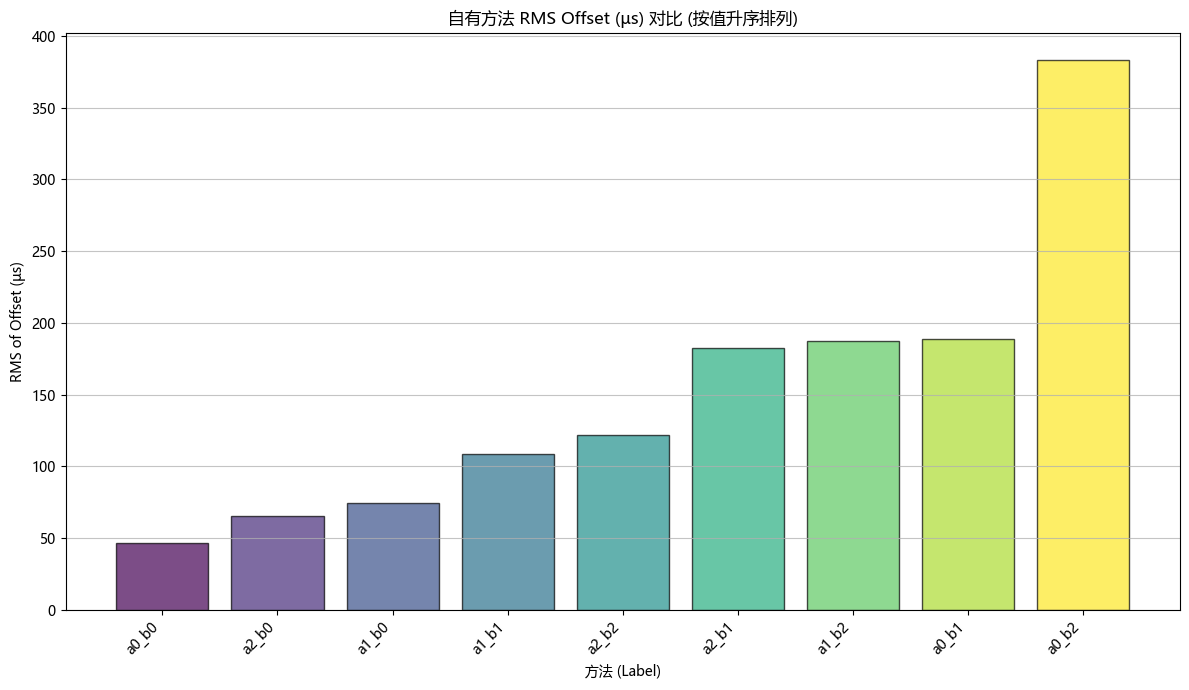

In [4]:
plt.figure(figsize=(12, 7)) # 调整图形大小以容纳标签
sorted_df_rms = own_methods_df.sort_values(by='RMS of Offset')
# 为每个条形生成不同的颜色
colors_rms = plt.cm.viridis(np.linspace(0, 1, len(sorted_df_rms)))
plt.bar(sorted_df_rms['Label'], sorted_df_rms['RMS of Offset'], color=colors_rms, edgecolor='black', alpha=0.7)
plt.title('自有方法 RMS Offset (µs) 对比 (按值升序排列)')
plt.xlabel('方法 (Label)')
plt.ylabel('RMS of Offset (µs)')
plt.xticks(rotation=45, ha='right') # 旋转X轴标签以防重叠
plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # 调整布局
plt.show()

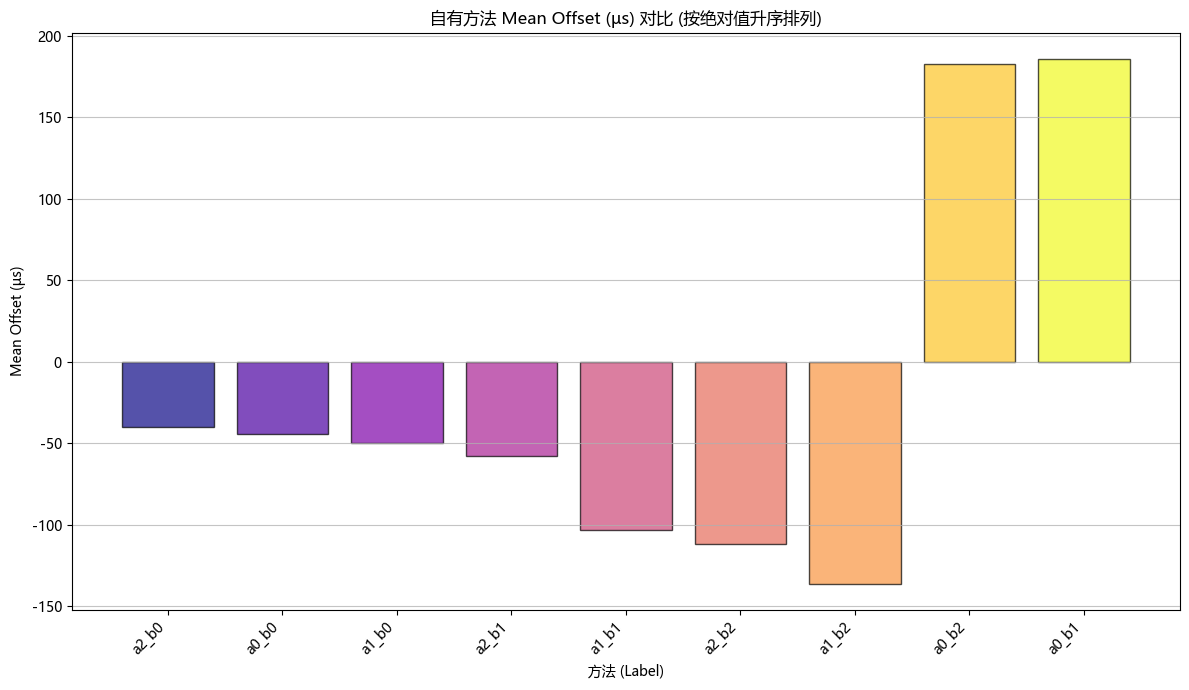

In [5]:
plt.figure(figsize=(12, 7))
# 根据 Mean Offset 的绝对值进行排序
own_methods_df['Abs Mean Offset'] = own_methods_df['Mean Offset'].abs()
sorted_df_mean = own_methods_df.sort_values(by='Abs Mean Offset')
# 为每个条形生成不同的颜色
colors_mean = plt.cm.plasma(np.linspace(0, 1, len(sorted_df_mean)))
plt.bar(sorted_df_mean['Label'], sorted_df_mean['Mean Offset'], color=colors_mean, edgecolor='black', alpha=0.7)
plt.title('自有方法 Mean Offset (µs) 对比 (按绝对值升序排列)')
plt.xlabel('方法 (Label)')
plt.ylabel('Mean Offset (µs)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

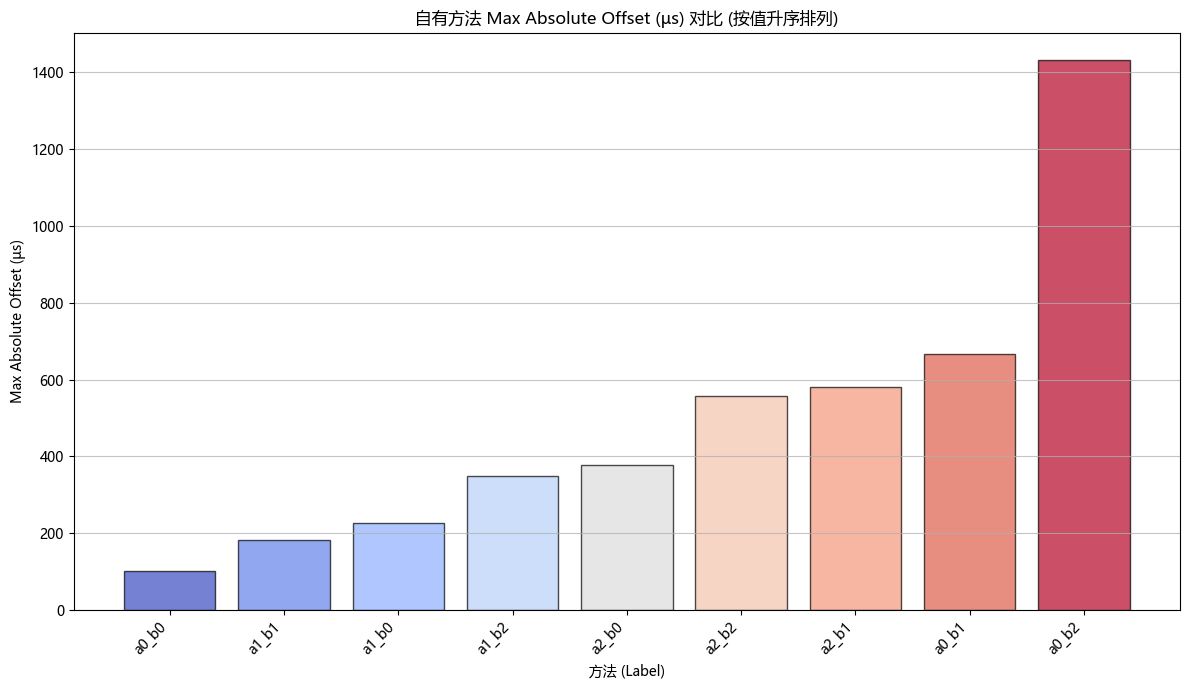

In [6]:
plt.figure(figsize=(12, 7))
sorted_df_max_abs = own_methods_df.sort_values(by='Max Absolute Offset')
# 为每个条形生成不同的颜色
colors_max_abs = plt.cm.coolwarm(np.linspace(0, 1, len(sorted_df_max_abs)))
plt.bar(sorted_df_max_abs['Label'], sorted_df_max_abs['Max Absolute Offset'], color=colors_max_abs, edgecolor='black', alpha=0.7)
plt.title('自有方法 Max Absolute Offset (µs) 对比 (按值升序排列)')
plt.xlabel('方法 (Label)')
plt.ylabel('Max Absolute Offset (µs)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## 3. 最佳自有方法 vs. Chrony 直方图比较

首先，我们根据 RMS Offset 找出最佳的自有方法。

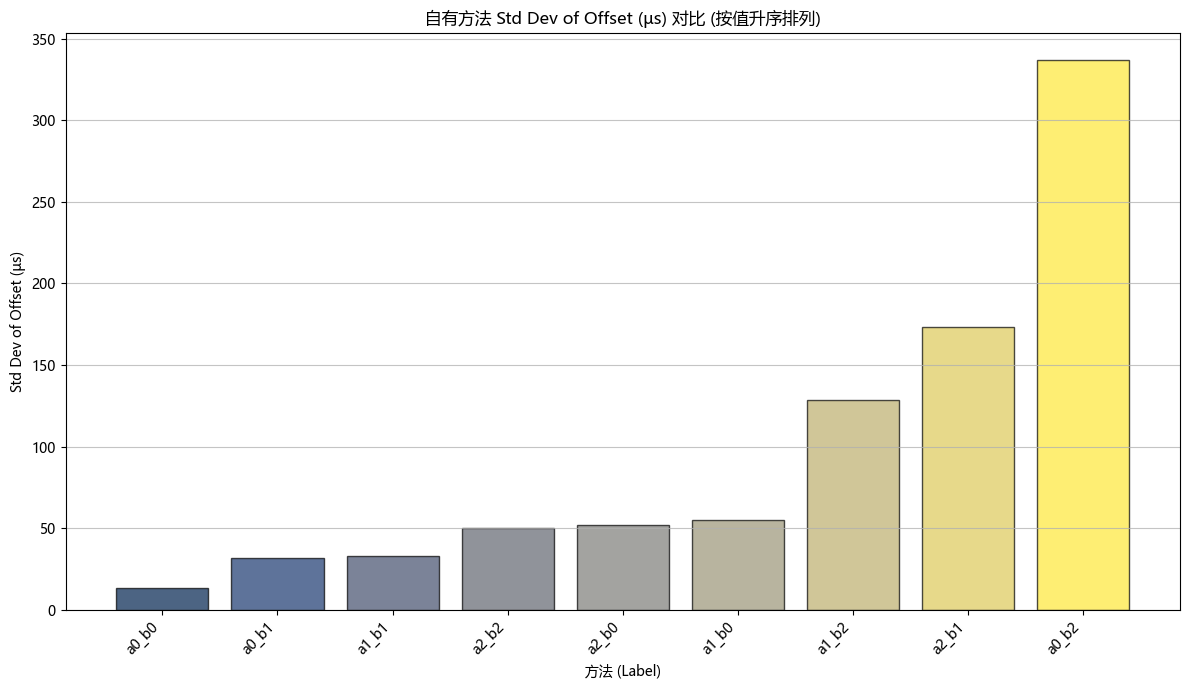

In [7]:
plt.figure(figsize=(12, 7))
sorted_df_std_dev = own_methods_df.sort_values(by='Std Dev of Offset')
# 为每个条形生成不同的颜色
colors_std_dev = plt.cm.cividis(np.linspace(0, 1, len(sorted_df_std_dev)))
plt.bar(sorted_df_std_dev['Label'], sorted_df_std_dev['Std Dev of Offset'], color=colors_std_dev, edgecolor='black', alpha=0.7)
plt.title('自有方法 Std Dev of Offset (µs) 对比 (按值升序排列)')
plt.xlabel('方法 (Label)')
plt.ylabel('Std Dev of Offset (µs)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [8]:
# 找到 RMS 最小的自有方法
best_own_method_label = own_methods_df.loc[own_methods_df['RMS of Offset'].idxmin()]['Label']
best_own_method_df = own_methods_df[own_methods_df['Label'] == best_own_method_label]

print(f"最佳自有方法 (基于最低 RMS Offset): {best_own_method_label}")
print(best_own_method_df)
print("\nChrony 数据:")
print(chrony_df)

最佳自有方法 (基于最低 RMS Offset): a0_b0
   Label                                 File  Mean Offset  \
0  a0_b0  timeError_a0_b0_20250222_105437.log      -44.488   

   Max Absolute Offset  RMS of Offset  Std Dev of Offset  Data Points  \
0              101.865         46.437              13.31         7100   

   Abs Mean Offset  
0           44.488  

Chrony 数据:
    Label           File  Mean Offset  Max Absolute Offset  RMS of Offset  \
9  Chrony  timeError.log     -344.017             12289.78        963.358   

   Std Dev of Offset  Data Points  
9            899.902         7155  


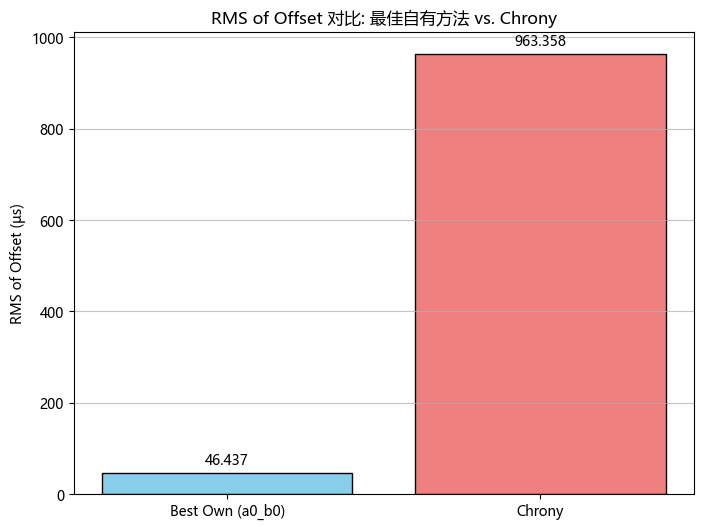

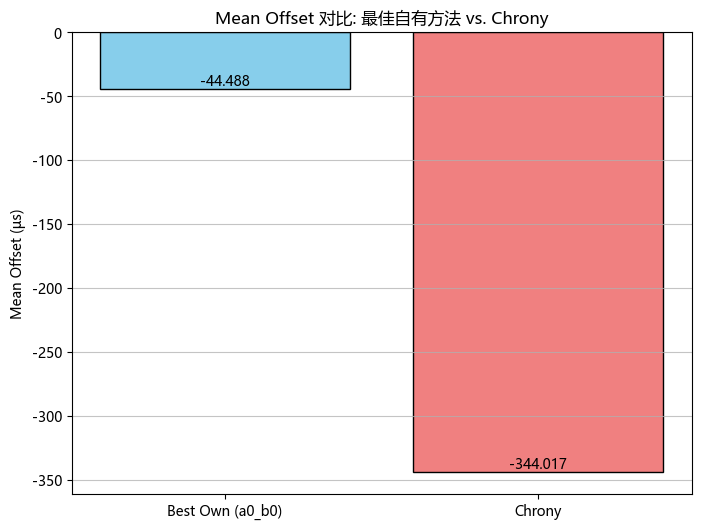

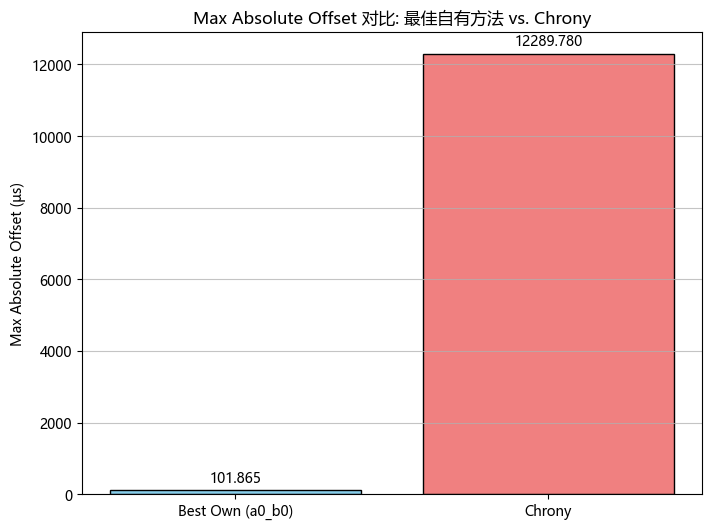

In [9]:
metrics_to_compare = ['RMS of Offset', 'Mean Offset', 'Max Absolute Offset', 'Std Dev of Offset']
method_names = [f"Best Own ({best_own_method_label})", "Chrony"]

for metric in metrics_to_compare:
    plt.figure(figsize=(8, 6))
    
    best_own_value = best_own_method_df[metric].values[0]
    chrony_value = chrony_df[metric].values[0]
    
    values = [best_own_value, chrony_value]
    
    bars = plt.bar(method_names, values, color=['skyblue', 'lightcoral'], edgecolor='black')
    
    plt.title(f'{metric} 对比: 最佳自有方法 vs. Chrony')
    plt.ylabel(f'{metric} (µs)')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01 * max(abs(best_own_value), abs(chrony_value), 0.1), f'{yval:.3f}', ha='center', va='bottom')

    plt.grid(axis='y', alpha=0.75)
    plt.show()